## IMDB Sentiment Analysis 
-----------------------------------------------------

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RepeatedKFold, RandomizedSearchCV
from random import randint

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB


import scipy
scipy.interp = np.interp
from scipy.stats import loguniform, uniform

from sklearn.metrics import *
from scikitplot.metrics import plot_roc_curve as auc_roc
import pickle


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from warnings import filterwarnings
filterwarnings("ignore")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhushan.chitte\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bhushan.chitte\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhushan.chitte\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bhushan.chitte\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Load dataset

In [9]:
df = pd.read_csv("../datasets/IMDB Dataset.csv")
df.shape

(50000, 2)

In [10]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [12]:
df.sample(5)

,review,sentiment
27195,Think of this film as a Saturday morning live-...,negative
21458,I absolutely love Promised Land. The first epi...,positive
11844,John Scott (John Wayne) and partner Kansas Cha...,negative
40250,I stumbled upon this movie by accident. I mean...,positive
18446,A fine ironic visual gag takes place in front ...,positive


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [14]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(418)

### Text Preprocessing

In [16]:
# Basic text cleaning

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]','', text) 
    text = re.sub(r'\s+',' ', text).strip() # remove extra space
    return text

df["review"] = df["review"].apply(clean_text)
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production br br the filmin...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,i am a catholic taught in parochial elementary...,negative
49998,im going to have to disagree with the previous...,negative


In [17]:
# Tokenization

df["review"] = df["review"].apply(word_tokenize)
df["review"]

0        [one, of, the, other, reviewers, has, mentione...
1        [a, wonderful, little, production, br, br, the...
2        [i, thought, this, was, a, wonderful, way, to,...
3        [basically, theres, a, family, where, a, littl...
4        [petter, matteis, love, in, the, time, of, mon...
                               ...                        
49995    [i, thought, this, movie, did, a, down, right,...
49996    [bad, plot, bad, dialogue, bad, acting, idioti...
49997    [i, am, a, catholic, taught, in, parochial, el...
49998    [im, going, to, have, to, disagree, with, the,...
49999    [no, one, expects, the, star, trek, movies, to...
Name: review, Length: 50000, dtype: object

In [18]:
# Remove stopwords
stop_words = set(stopwords.words("english"))

df["review"] = df["review"].apply(lambda x: [word for word in x if word not in stop_words])
df["review"]

0        [one, reviewers, mentioned, watching, oz, epis...
1        [wonderful, little, production, br, br, filmin...
2        [thought, wonderful, way, spend, time, hot, su...
3        [basically, theres, family, little, boy, jake,...
4        [petter, matteis, love, time, money, visually,...
                               ...                        
49995    [thought, movie, right, good, job, wasnt, crea...
49996    [bad, plot, bad, dialogue, bad, acting, idioti...
49997    [catholic, taught, parochial, elementary, scho...
49998    [im, going, disagree, previous, comment, side,...
49999    [one, expects, star, trek, movies, high, art, ...
Name: review, Length: 50000, dtype: object

In [19]:
# stemming or lemmatization

# stemmer = PorterStemmer()
# df["review"] = df["review"].apply(lambda x: [stemmer.stem(word) for word in x])
# df["review"]

lemmatizer = WordNetLemmatizer()

df["review"] = df["review"].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
df["review"]

0        [one, reviewer, mentioned, watching, oz, episo...
1        [wonderful, little, production, br, br, filmin...
2        [thought, wonderful, way, spend, time, hot, su...
3        [basically, there, family, little, boy, jake, ...
4        [petter, matteis, love, time, money, visually,...
                               ...                        
49995    [thought, movie, right, good, job, wasnt, crea...
49996    [bad, plot, bad, dialogue, bad, acting, idioti...
49997    [catholic, taught, parochial, elementary, scho...
49998    [im, going, disagree, previous, comment, side,...
49999    [one, expects, star, trek, movie, high, art, f...
Name: review, Length: 50000, dtype: object

In [20]:
# Join tokens back

df["review"] = df["review"].apply(lambda x: " ".join(x))
df["review"]

0        one reviewer mentioned watching oz episode you...
1        wonderful little production br br filming tech...
2        thought wonderful way spend time hot summer we...
3        basically there family little boy jake think t...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job wasnt creative or...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    im going disagree previous comment side maltin...
49999    one expects star trek movie high art fan expec...
Name: review, Length: 50000, dtype: object

In [21]:
# convert text to numerical features

# vectorizer = CountVectorizer()
# X = vectorizer.fit_transform(df["review"])

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["review"])
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4876350 stored elements and shape (50000, 164685)>

In [22]:
y = df['sentiment'].map({'positive':1, 'negative':0})

### Train ML Models

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape} & y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape} & y_test shape: {y_test.shape}")

X_train shape: (40000, 164685) & y_train shape: (40000,)
X_test shape: (10000, 164685) & y_test shape: (10000,)


In [24]:
Evaluation_Results = pd.DataFrame(np.zeros((3,5)), columns=['Accuracy', 'Precision','Recall','F1-score','AUC-ROC score'])
Evaluation_Results.index=['Logistic Regression (LR)', 'Support Vector Machine (SVM)','Naive Bayes (NB)']
Evaluation_Results

,Accuracy,Precision,Recall,F1-score,AUC-ROC score
Logistic Regression (LR),0.0,0.0,0.0,0.0,0.0
Support Vector Machine (SVM),0.0,0.0,0.0,0.0,0.0
Naive Bayes (NB),0.0,0.0,0.0,0.0,0.0


In [25]:
def AUC_ROC_plot(Test_Y, pred_prob_pos):
    # Baseline (random classifier)
    ref = [0 for _ in range(len(Test_Y))]

    ns_fpr, ns_tpr, _ = roc_curve(Test_Y, ref)
    lr_fpr, lr_tpr, _ = roc_curve(Test_Y, pred_prob_pos)

    plt.plot(ns_fpr, ns_tpr, linestyle='--', label='Random')
    plt.plot(lr_fpr, lr_tpr, marker='.', label='Model AUC = {}'.format(round(roc_auc_score(Test_Y, pred_prob_pos)*100, 2))) 
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

In [26]:
def Classification_Summary(pred, pred_prob, i, y_test, Evaluation_Results):
    # Ensure y_test is 1D (handle one-hot encoding)
    if len(y_test.shape) == 2 and y_test.shape[1] == 2:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test

    # If pred_prob is 2D (from predict_proba), take positive class
    if pred_prob.ndim == 2 and pred_prob.shape[1] == 2:
        pred_prob_pos = pred_prob[:, 1]
    else:
        pred_prob_pos = pred_prob

    # Metrics
    Evaluation_Results.iloc[i]['Accuracy'] = round(accuracy_score(y_true, pred), 3)*100
    Evaluation_Results.iloc[i]['Precision'] = round(precision_score(y_true, pred, average='weighted'), 3)*100
    Evaluation_Results.iloc[i]['Recall'] = round(recall_score(y_true, pred, average='weighted'), 3)*100
    Evaluation_Results.iloc[i]['F1-score'] = round(f1_score(y_true, pred, average='weighted'), 3)*100
    Evaluation_Results.iloc[i]['AUC-ROC score'] = round(roc_auc_score(y_true, pred_prob_pos), 3)*100

    print('{}{}\033[1m Evaluating {} \033[0m{}{}\n'.format('<'*3,'-'*35, Evaluation_Results.index[i], '-'*35,'>'*3))
    print('Accuracy = {}%'.format(round(accuracy_score(y_true, pred), 3)*100))
    print('F1 Score = {}%'.format(round(f1_score(y_true, pred, average='weighted'), 3)*100))
    print('\n\033[1mConfusion Matrix:\033[0m\n', confusion_matrix(y_true, pred))
    print('\n\033[1mClassification Report:\033[0m\n', classification_report(y_true, pred))

    AUC_ROC_plot(y_true, pred_prob_pos)

<<<----------------------------------- Evaluating Logistic Regression (LR) ----------------------------------->>>

Accuracy = 90.0%
F1 Score = 90.0%

Confusion Matrix:
 [[4416  545]
 [ 456 4583]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



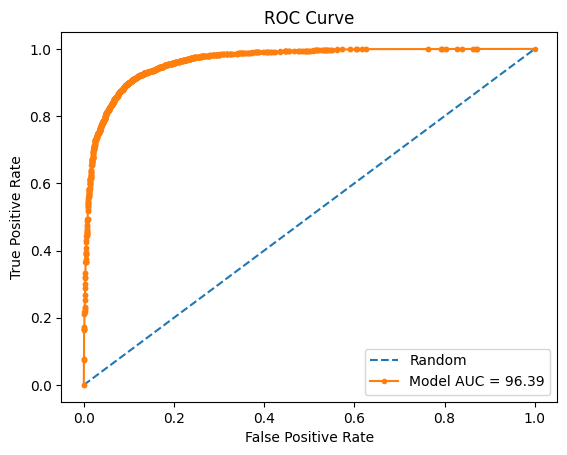


Interpreting the Output of Logistic Regression:

Intercept: -0.1505418594447278
Classes: [0 1]


In [27]:
# Building Logistic Regression Classifier

# Base model
LR_model = LogisticRegression(max_iter=1000)

# Hyperparameter space
space = {
    'solver': ['newton-cg', 'lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'C': loguniform(1e-5, 100)
}

# Randomized Search
RCV = RandomizedSearchCV(
    LR_model,
    param_distributions=space,
    n_iter=50,
    scoring='accuracy',
    n_jobs=-1,
    cv=5,
    random_state=1
)

# Fit the search
LR = RCV.fit(X_train, y_train).best_estimator_

# Predictions
pred = LR.predict(X_test)
pred_prob = LR.predict_proba(X_test)

# Evaluation
Classification_Summary(pred, pred_prob, 0, y_test, Evaluation_Results)

print('\n\033[1mInterpreting the Output of Logistic Regression:\n\033[0m')

print('Intercept:', LR.intercept_[0])
print('Classes:', LR.classes_)

<<<----------------------------------- Evaluating Support Vector Machine (SVM) ----------------------------------->>>

Accuracy = 89.7%
F1 Score = 89.7%

Confusion Matrix:
 [[4406  555]
 [ 470 4569]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.90      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



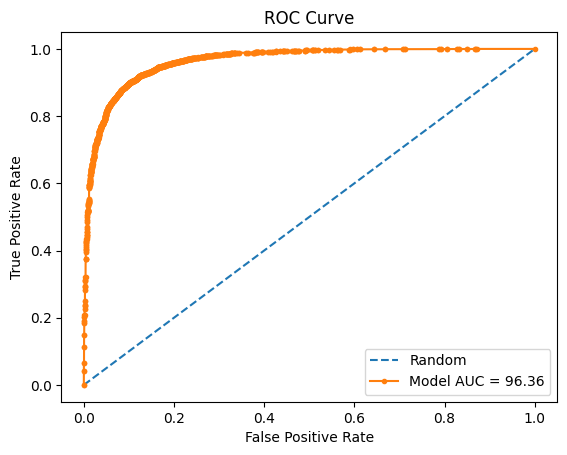


Interpreting the Output of LinearSVC:

Classes: [0 1]


In [28]:
# Building LinearSVC

# Base model
SVC_model = LinearSVC()

# Hyperparameter space
space = {
    'C': loguniform(1e-5, 100),
    'loss': ['hinge', 'squared_hinge'],
    'max_iter': [1000, 2000, 5000]
}

# Randomized Search
RCV = RandomizedSearchCV(
    SVC_model,
    param_distributions=space,
    n_iter=50,
    scoring='accuracy',
    n_jobs=-1,
    cv=5,
    random_state=1
)

# Fit
SVC = RCV.fit(X_train, y_train).best_estimator_

# Predictions
pred = SVC.predict(X_test)

# Use decision_function instead of predict_proba
pred_prob = SVC.decision_function(X_test)

# Evaluation
Classification_Summary(pred, pred_prob, 1, y_test, Evaluation_Results)

print('\n\033[1mInterpreting the Output of LinearSVC:\n\033[0m')

print('Classes:', SVC.classes_)

<<<----------------------------------- Evaluating Naive Bayes (NB) ----------------------------------->>>

Accuracy = 86.9%
F1 Score = 86.9%

Confusion Matrix:
 [[4358  603]
 [ 709 4330]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87      4961
           1       0.88      0.86      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



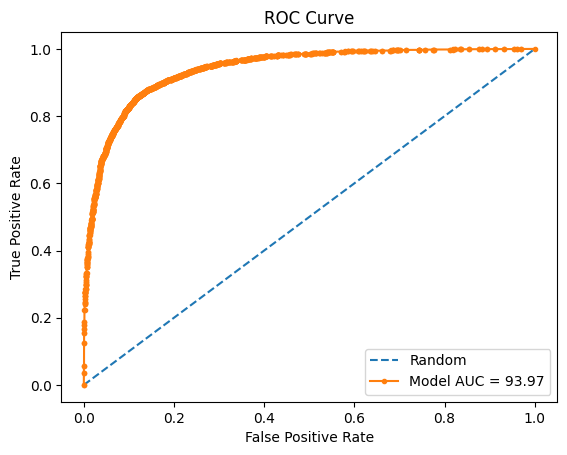


Interpreting the Output of MultinomialNB:

Class Log Prior: [-0.69314718 -0.69314718]
Classes: [0 1]


In [29]:
# Building MultinomialNB

# Base model
NB_model = MultinomialNB()

# Hyperparameter space
space = {
    'alpha': uniform(0.0, 1.0),   
    'fit_prior': [True, False]
}

# Randomized Search
RCV = RandomizedSearchCV(
    NB_model,
    param_distributions=space,
    n_iter=50,
    scoring='accuracy',
    n_jobs=-1,
    cv=5,
    random_state=1
)

# Fit
NB = RCV.fit(X_train, y_train).best_estimator_

# Predictions
pred = NB.predict(X_test)
pred_prob = NB.predict_proba(X_test)

# Evaluation
Classification_Summary(pred, pred_prob, 2, y_test, Evaluation_Results)

print('\n\033[1mInterpreting the Output of MultinomialNB:\n\033[0m')

print('Class Log Prior:', NB.class_log_prior_)
print('Classes:', NB.classes_)

                                    ML Algorithms Comparison                                    


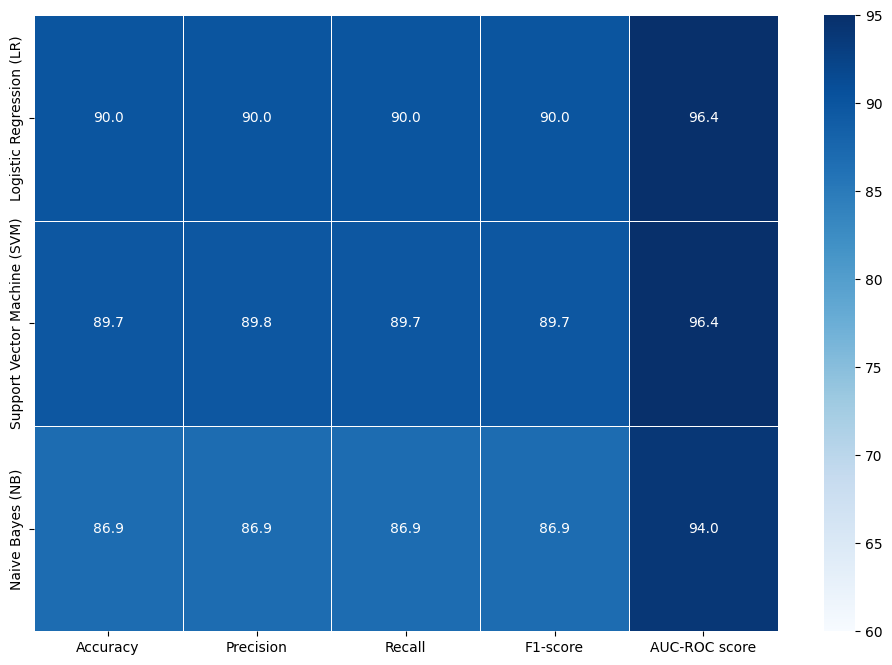

In [30]:
#Comparing all the models Scores

print('\033[1mML Algorithms Comparison'.center(100))
plt.figure(figsize=[12,8])
sns.heatmap(Evaluation_Results, annot=True, vmin=60, vmax=95, cmap='Blues', fmt='.1f', linewidths=0.5)
plt.show()

### Model Saving

In [32]:
with open("../NLP/sentiment_analysis_model.pkl", "wb") as f:
    pickle.dump(LR, f)


with open("../NLP/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

### Model Testing

In [66]:
with open("../NLP/vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

with open("../NLP/sentiment_analysis_model.pkl", "rb") as f:
    model = pickle.load(f)

text = ["This movie was absolutely bad!"]
X = vectorizer.transform(text)

# Predictions
pred = model.predict(X)

if pred == 1:
    print("Positive Review")
else:
    print("Negative Review")

Negative Review


------------------------------------------------
## VADER (Valence Aware Dictionary and Sentiment Reasoner)
- is a sentiment analysis tool which is designed to analyze social media text and informal language. Unlike traditional sentiment analysis methods it is best at detecting sentiment in short pieces of text like tweets, product reviews or user comments which contain slang, emojis and abbreviations. It uses a pre-built lexicon of words associated with sentiment values and applies specific rules to calculate sentiment scores.

### How VADER Works?
- VADER works by analyzing the polarity of words and assigning a sentiment score to each word based on its emotional value. These individual word scores are then combined to calculate an overall sentiment score for the entire text.

- It uses compound score which is a normalized value between -1 and +1 representing the overall sentiment:
    - Compound score > 0.05: Positive sentiment
    - Compound score < -0.05: Negative sentiment
    - Compound score between -0.05 and 0.05: Neutral sentiment

In [75]:
# from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bhushan.chitte\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [76]:
def sentiment_scores(text):
    analyzer = SentimentIntensityAnalyzer()
    sentiment_dict = analyzer.polarity_scores(text)

    print(f"Sentiment Scores: {sentiment_dict}")
    print(f"Negative Sentiment: {np.round(sentiment_dict['neg']*100, 2)}%")
    print(f"Neutral Sentiment: {np.round(sentiment_dict['neu']*100, 2)}%")
    print(f"Positive Sentiment: {np.round(sentiment_dict['pos']*100, 2)}%")

    if sentiment_dict['compound'] >= 0.05:
        print("Overall Sentiment: Positive")
    elif sentiment_dict['compound'] <= -0.05:
        print("Overall Sentiment: Negative")
    else:
        print("Overall Sentiment: Neutral")

In [80]:
text = "This movie was not good"
sentiment_scores(text)

Sentiment Scores: {'neg': 0.376, 'neu': 0.624, 'pos': 0.0, 'compound': -0.3412}
Negative Sentiment: 37.6%
Neutral Sentiment: 62.4%
Positive Sentiment: 0.0%
Overall Sentiment: Negative
